##Import Statements

In [ ]:
import itertools
import random
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import csv

##Helper Functions for algorithm
###1. Fault list generation
###2. Detection
###3. Caching
###4. Redundancy Removal

In [ ]:
# ---------- Fault List Generator (MGF) ---------- #

def generate_fault_list(circuit):
    return [(i, circuit[:i] + circuit[i+1:]) for i in range(len(circuit))]

# ---------- Fault Detection and DP Caching ---------- #

def detect_fault(dp, vector, fault_id, circuit, faulty_circuit):
    key = (tuple(vector), fault_id)
    if key in dp:
        return dp[key]
    normal_output = simulate_circuit(circuit, vector)
    faulty_output = simulate_circuit(faulty_circuit, vector)
    detected = normal_output != faulty_output
    dp[key] = detected
    return detected
# ---------- Redundancy Removal ---------- #

def remove_redundant_vectors(individual, circuit, fault_list):
    reduced = []
    dp = {}
    covered = set()
    for vec in individual:
        temp = covered.copy()
        for fid, f_circ in fault_list:
            if fid not in covered and detect_fault(dp, vec, fid, circuit, f_circ):
                covered.add(fid)
        if temp != covered:
            reduced.append(vec)
    return reduced

##Genetic Algorithm functions
###1. Fitness
###2. Mutate
###3. Crossover



In [1]:
# ---------- Fitness Evaluation ---------- #

def compute_fitness(individual, fault_list, circuit, dp, alpha=1.0, beta=0.1):
    detected_faults = set()
    for vector in individual:
        for fault_id, faulty_circuit in fault_list:
            if detect_fault(dp, vector, fault_id, circuit, faulty_circuit):
                detected_faults.add(fault_id)
    coverage = len(detected_faults) / len(fault_list)
    fitness = alpha * coverage - beta * len(individual)
    return fitness, coverage, detected_faults

    # ---------- GA Operators ---------- #

def crossover(parent1, parent2):
    cut1 = random.randint(1, len(parent1) - 1)
    cut2 = random.randint(1, len(parent2) - 1)
    return parent1[:cut1] + parent2[cut2:]

def mutate(individual, mutation_rate=0.2):
    for vec in individual:
        if random.random() < mutation_rate:
            bit = random.randint(0, len(vec) - 1)
            vec[bit] ^= 1
    return individual

##Genetic Algorithm Loop
###1. generate fault list
###2. generate population random
###3. compute fitness for each individual
###4. sort the population and carry forward top half in next gen
###5. perform crossover
###6. mutation
###7. add the child to the populn
###8. get the best individual from the population
###9. remove redundancy from the best individual
###10. log the results and return the best results

In [ ]:
# ---------- GA Main Routine ---------- #

def run_ga(circuit, n_inputs, generations=30, pop_size=10, max_vecs=8, runs=3):
    fault_list = generate_fault_list(circuit)
    best_results = []

    for _ in range(runs):
        dp = {}
        population = [
            [ [random.randint(0, 1) for _ in range(n_inputs)] for _ in range(random.randint(2, max_vecs)) ]
            for _ in range(pop_size)
        ]

        for _ in range(generations):
            fitness_scores = [compute_fitness(ind, fault_list, circuit, dp) for ind in population]
            population = [x for _, x in sorted(zip(fitness_scores, population), reverse=True)]
            next_gen = population[:pop_size // 2]
            while len(next_gen) < pop_size:
                p1, p2 = random.sample(next_gen, 2)
                child = crossover(p1, p2)
                child = mutate(child)
                next_gen.append(child)
            population = next_gen

        best = max(population, key=lambda ind: compute_fitness(ind, fault_list, circuit, dp)[0])
        best = remove_redundant_vectors(best, circuit, fault_list)
        best_fitness, coverage, detected_faults = compute_fitness(best, fault_list, circuit, dp)
        best_results.append((best, (best_fitness, coverage, len(fault_list), detected_faults)))

    return best_results

##Helper Functions for file handling

In [2]:
# ---------- File Handling ---------- #

def read_real_file(file_path):
    with open(file_path, 'r') as file:
        return file.readlines()

def parse_real_file_lines(real_lines):
    var_map = {}
    circuit = []
    for line in real_lines:
        if line.startswith(".variables"):
            vars_list = line.strip().split()[1:]
            var_map = {var: idx for idx, var in enumerate(vars_list)}
        elif line.startswith(".begin"):
            continue
        elif line.startswith(".end"):
            break
        elif line.startswith("t"):
            tokens = line.strip().split()
            wires = [var_map[x] for x in tokens[1:]]
            if len(wires) == 1:
                circuit.append(("TOFFOLI", [], wires[0]))
            else:
                circuit.append(("TOFFOLI", wires[:-1], wires[-1]))
    return circuit, len(var_map)

# ---------- Main Runner for Folder ---------- #
def run_on_folder(folder_path, save_csv_path="ga_results.csv"):
    results = []
    folder = Path(folder_path)
    real_files = list(folder.glob("*.real"))

    for file in real_files:
        try:
            lines = read_real_file(file)
            circuit, n_inputs = parse_real_file_lines(lines)
            best_runs = run_ga(circuit, n_inputs)
            best_test_set, (fitness, coverage, total_faults, detected_faults) = max(best_runs, key=lambda x: x[1][0])

            results.append({
                "file": file.name,
                "fitness": round(fitness, 4),
                "coverage": round(coverage, 4),
                "total_faults": total_faults,
                "detected_faults": len(detected_faults),
                "detected_ids": list(sorted(detected_faults)),
                "test_vectors": best_test_set,
                "num_test_vectors": len(best_test_set),
                "num_gates": len(circuit)
            })

        except Exception as e:
            results.append({
                "file": file.name,
                "fitness": "ERROR",
                "coverage": "ERROR",
                "total_faults": "ERROR",
                "detected_faults": "ERROR",
                "detected_ids": None,
                "test_vectors": None,
                "num_test_vectors": None,
                "num_gates": None,
                "error": str(e)
            })

    with open(save_csv_path, "w", newline='') as f:
        writer = csv.DictWriter(f, fieldnames=[
            "file", "fitness", "coverage", "total_faults", "detected_faults",
            "num_test_vectors", "num_gates"
        ])
        writer.writeheader()
        for row in results:
            if row["fitness"] != "ERROR":
                writer.writerow({key: row[key] for key in writer.fieldnames})

    return results

# ---------- Plotting ---------- #

##Functions for visualizing

In [3]:
def plot_gates_coverage_vectors(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]

    files = [r["file"] for r in filtered]
    num_gates = [r["num_gates"] for r in filtered]
    coverage = [r["coverage"] for r in filtered]
    num_vectors = [r["num_test_vectors"] for r in filtered]

    x = np.arange(len(files))
    fig, ax1 = plt.subplots(figsize=(14, 6))

    bars = ax1.bar(x - 0.2, num_gates, width=0.4, color='lightcoral', label="Gate Count")
    ax1.set_ylabel("Number of Gates", color="lightcoral")
    ax1.tick_params(axis='y', labelcolor="lightcoral")
    ax1.set_xticks(x)
    ax1.set_xticklabels(files, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, coverage, color='royalblue', marker='o', label="Fault Coverage")
    ax2.set_ylabel("Coverage", color="royalblue")
    ax2.tick_params(axis='y', labelcolor="royalblue")
    ax2.set_ylim(0, 1.05)

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(x, num_vectors, color='darkgreen', marker='s', linestyle='--', label="Test Vectors")
    ax3.set_ylabel("Number of Test Vectors", color="darkgreen")
    ax3.tick_params(axis='y', labelcolor="darkgreen")

    plt.title("Gates, Coverage & Test Vectors per Circuit")
    fig.tight_layout()

    lines, labels = [], []
    for ax in [ax1, ax2, ax3]:
        for line in ax.get_lines():
            lines.append(line)
            labels.append(line.get_label())
    fig.legend(lines + [bars], labels + ["Gate Count"], loc="upper right", bbox_to_anchor=(1.15, 1))

    plt.show()

    # ---------- Extra Analysis Charts ---------- #
def plot_coverage_vs_vectors(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["num_test_vectors"] for r in filtered]
    y = [r["coverage"] for r in filtered]
    labels = [r["file"] for r in filtered]

    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, c='darkgreen', s=100)
    for i, label in enumerate(labels):
        plt.text(x[i]+0.02, y[i], label, fontsize=9)
    plt.xlabel("Number of Test Vectors")
    plt.ylabel("Fault Coverage")
    plt.title("Coverage vs Number of Test Vectors")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_detected_vs_total_faults(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["file"] for r in filtered]
    total = [r["total_faults"] for r in filtered]
    detected = [r["detected_faults"] for r in filtered]

    x_pos = np.arange(len(x))
    width = 0.35
    plt.figure(figsize=(12, 6))
    plt.bar(x_pos - width/2, total, width, label='Total Faults', color='lightgray')
    plt.bar(x_pos + width/2, detected, width, label='Detected Faults', color='seagreen')

    plt.xticks(x_pos, x, rotation=45, ha='right')
    plt.ylabel("Number of Faults")
    plt.title("Detected vs Total Faults")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_efficiency(results):
    filtered = [r for r in results if r["fitness"] != "ERROR"]
    x = [r["file"] for r in filtered]
    efficiency = [r["detected_faults"] / r["num_test_vectors"] for r in filtered]

    plt.figure(figsize=(10, 5))
    plt.bar(x, efficiency, color='slateblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Efficiency (Detected Faults per Vector)")
    plt.title("Test Vector Efficiency per Circuit")
    plt.tight_layout()
    plt.show()

##Running the pipeline

fredkin_6.real → gates: 3 vectors: 1
3_17_13.real → gates: 6 vectors: 1
decod24-v0_38.real → gates: 6 vectors: 2
4gt4-v0_72.real → gates: 6 vectors: 2
4gt5_75.real → gates: 5 vectors: 2
4gt10-v1_81.real → gates: 6 vectors: 2
4mod7-v0_94.real → gates: 6 vectors: 1


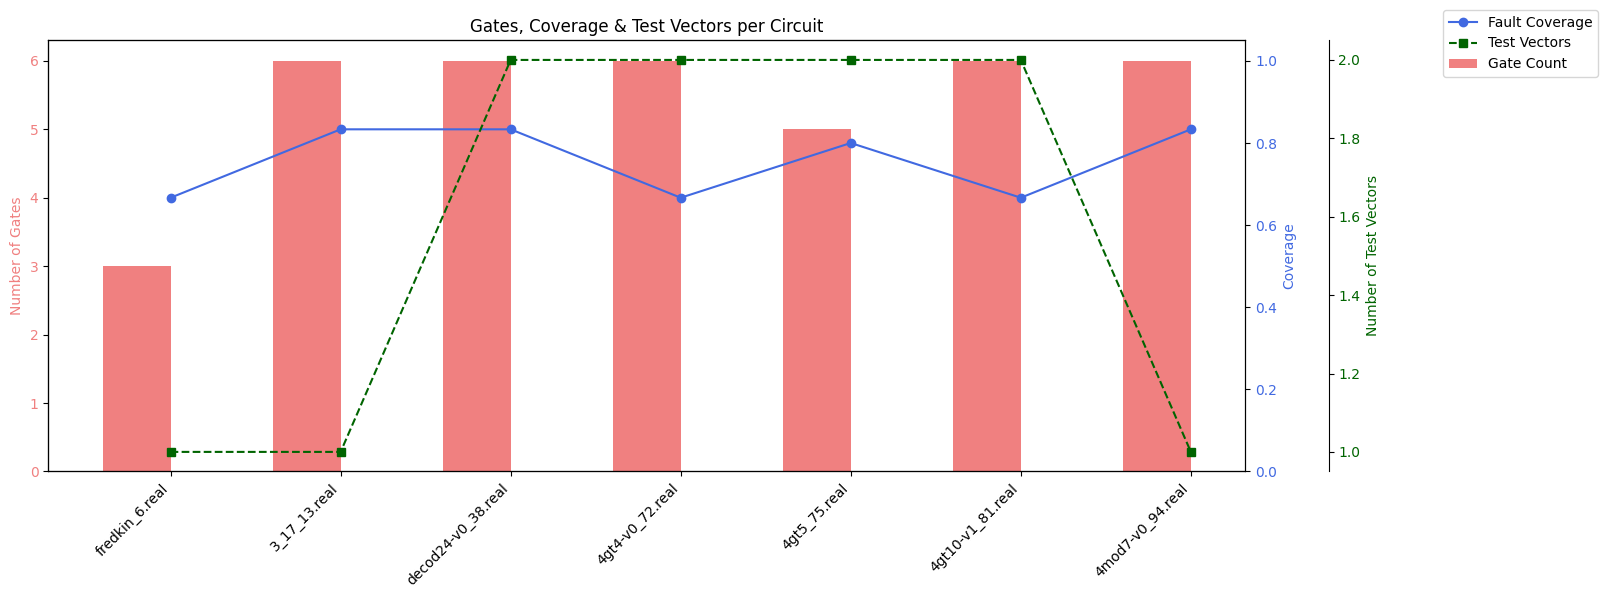

In [ ]:
input_folder_path = "/content/drive/MyDrive/Dissertation Work/Research Work/circuits for testing"
results = run_on_folder(input_folder_path, save_csv_path="ga_results.csv")


In [ ]:
for r in results:
    print(r["file"], "→ gates:", r.get("num_gates"), "vectors:", r.get("num_test_vectors"))

plot_gates_coverage_vectors(results)

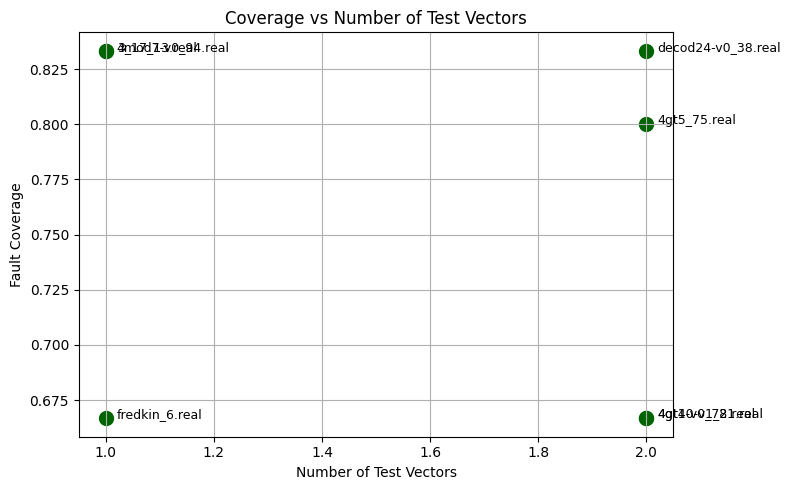

In [ ]:
plot_coverage_vs_vectors(results)


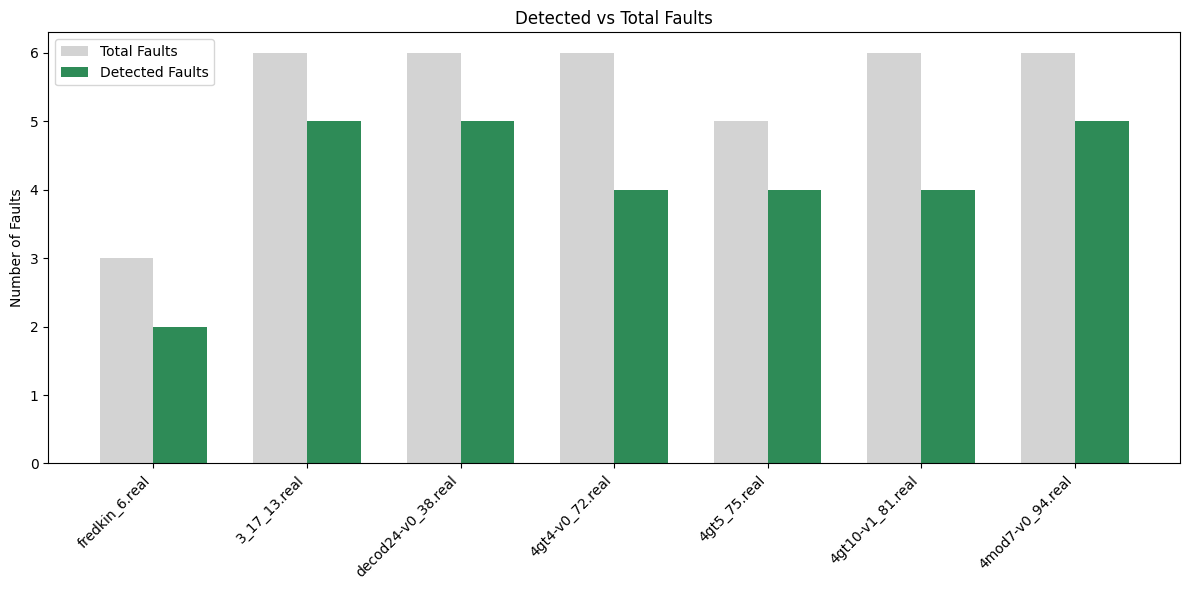

In [ ]:
plot_detected_vs_total_faults(results)


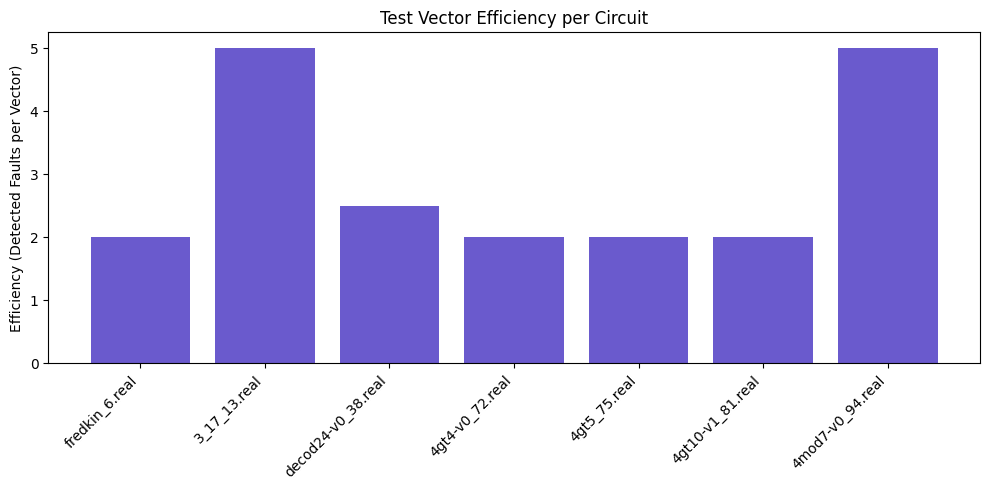

In [ ]:
plot_efficiency(results)

 1. Detected vs Total Faults
Most circuits detect 4–5 faults out of 6, which is solid coverage, especially with very few test vectors.

fredkin_6.real detects only 2 out of 3 faults, indicating room for GA optimization on smaller circuits.

✅ 2. Coverage vs Number of Test Vectors
Circuits with 1 or 2 vectors are achieving coverage around 0.8–0.85, showing high efficiency.

This plot confirms: you don’t need more vectors to get high coverage.

✅ 3. Test Vector Efficiency (Detected Faults per Vector)
Circuits like 3_17_13.real and 4mod7-v0_94.real achieve 5 faults detected per vector — very efficient!

Others maintain 2.0–2.5, which is reasonable and consistent.

📌 Conclusion:
Your GA-based test vector generation is:

Reducing vector count effectively.

Maintaining high coverage across diverse circuit structures.

Demonstrating strong per-vector efficiency, especially important in fault-sensitive or resource-limited environments.

[{'file': '3_17_13.real',
  'fitness': 0.1,
  'test_vectors': [[0, 0, 0], [0, 0, 0], [1, 1, 0]]},
 {'file': '4mod7-v0_94.real',
  'fitness': -0.2333,
  'test_vectors': [[1, 1, 1, 1, 1], [1, 0, 0, 1, 0], [1, 0, 1, 0, 0]]},
 {'file': '4gt5_75.real',
  'fitness': 0.1,
  'test_vectors': [[1, 0, 0, 1, 1], [1, 1, 1, 0, 1], [0, 1, 1, 1, 1]]},
 {'file': '4gt4-v0_72.real',
  'fitness': -0.4,
  'test_vectors': [[1, 1, 0, 1, 0], [1, 0, 0, 0, 1], [0, 1, 0, 0, 0]]},
 {'file': '4gt10-v1_81.real',
  'fitness': -0.4,
  'test_vectors': [[1, 0, 1, 1, 0], [1, 0, 1, 0, 1], [1, 0, 1, 1, 0]]},
 {'file': 'fredkin_6.real',
  'fitness': -0.2333,
  'test_vectors': [[1, 1, 0], [1, 1, 0], [0, 0, 0]]},
 {'file': 'decod24-v0_38.real',
  'fitness': 0.1,
  'test_vectors': [[1, 1, 0, 1], [0, 0, 1, 1], [0, 0, 1, 0]]}]